In [52]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

from sklearn.linear_model import RidgeClassifierCV, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import  StratifiedKFold
from sklearn.svm import SVC

from sklearn.model_selection import cross_validate
from sklearn.base import ClassifierMixin

from scipy import stats

import warnings
warnings.filterwarnings("ignore", module="sklearn")
warnings.filterwarnings("ignore", category=UserWarning)

from mil.CellsData import CellsData

# Baselines on mean- and max- aggregated data

In [53]:
train_set = CellsData(split="train")
val_set = CellsData(split="val")
test_set = CellsData(split="test")

In [54]:
#train set
X_sparse_max = []
X_sparse_mean = []

X_embed_max = []
X_embed_mean = []

y_train = []

#test set
X_test_sparse_max = []
X_test_sparse_mean = []

X_test_embed_max = []
X_test_embed_mean = []

y_test = []

for el in train_set:
    X_sparse_max.append(np.max(el['bag'].to_dense().numpy(), axis = 0))
    X_sparse_mean.append(np.sum(el['bag'].to_dense().numpy(), axis = 0))

    X_embed_max.append(np.max(el['bag_embed'].to_dense().numpy(), axis = 0))
    X_embed_mean.append(np.sum(el['bag_embed'].to_dense().numpy(), axis = 0))

    y_train.append(el['y'].numpy())

for el in val_set:
    X_sparse_max.append(np.max(el['bag'].to_dense().numpy(), axis = 0))
    X_sparse_mean.append(np.sum(el['bag'].to_dense().numpy(), axis = 0))

    X_embed_max.append(np.max(el['bag_embed'].to_dense().numpy(), axis = 0))
    X_embed_mean.append(np.sum(el['bag_embed'].to_dense().numpy(), axis = 0))

    y_train.append(el['y'].numpy())

for el in test_set:
    X_test_sparse_max.append(np.max(el['bag'].to_dense().numpy(), axis = 0))
    X_test_sparse_mean.append(np.sum(el['bag'].to_dense().numpy(), axis = 0))

    X_test_embed_max.append(np.max(el['bag_embed'].to_dense().numpy(), axis = 0))
    X_test_embed_mean.append(np.sum(el['bag_embed'].to_dense().numpy(), axis = 0))

    y_test.append(el['y'].numpy())

X_sparse_max = np.array(X_sparse_max)
X_sparse_mean = np.array(X_sparse_mean)

X_embed_max = np.array(X_embed_max)
X_embed_mean = np.array(X_embed_mean)

y_train = np.array(y_train)[:, 1]

#test set
X_test_sparse_max = np.array(X_test_sparse_max)
X_test_sparse_mean = np.array(X_test_sparse_mean)

X_test_embed_max = np.array(X_test_embed_max)
X_test_embed_mean = np.array(X_embed_mean)

y_test = np.array(y_test)[:, 1]

In [ ]:

def get_classifiers():
    options = dict()
    options['Ridge'] = RidgeClassifierCV(alphas = ( 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100), cv = 5, class_weight='balanced', fit_intercept = True)
    options['Lasso'] = LogisticRegressionCV(penalty='l1', Cs = (0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100), cv = 5, solver='saga', max_iter = 1000)
    options['Elastic Net'] = LogisticRegressionCV(penalty='elasticnet', Cs = (0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100), l1_ratios = [0.1, 0.5, 1], cv = 5, solver='saga', max_iter = 1000)
    options['SVM'] = SVC(C = 100, class_weight='balanced')
    options['Tree'] = DecisionTreeClassifier(max_depth = 30, class_weight='balanced')
    options['Random Forest'] = RandomForestClassifier(n_estimators = 50, max_depth = 5, class_weight='balanced')

    return options


def run_analysis_cv(classifiers: dict[str, ClassifierMixin], x_train, y_train, plot_title):
    result_dict = dict()
    clfs = dict()

    for classifier_name, clf in classifiers.items():
        scores = cross_validate(
            clf, x_train, y_train, scoring="balanced_accuracy", cv=StratifiedKFold(n_splits=5, shuffle=True)
        )

        print(classifier_name)
        mean = scores["test_score"].mean()
        sem = stats.sem(scores["test_score"])

        error = 1.96*sem
        print(f"Mean Balanced Accuracy: {mean:.3f} +/- {error:.3f}")
        acc_random = 0.5
        print(f"Balanced Accuracy with Random Labels: {acc_random:.3f}")
        print()

        result_dict[classifier_name] = (mean, sem)
        clfs[classifier_name] = clf

    fig, ax = plt.subplots(figsize = (8, 6))

    counter = 0
    for key, value in result_dict.items():
            ax.scatter(counter, value[0])
            ax.errorbar(counter, value[0], 1.96*value[1])
            counter +=1


    ax.set_ylim((0, 1))
    ax.legend()

    ax.set_title(plot_title)
    ax.set_xticks(range(len(result_dict.keys())))
    ax.set_xticklabels(result_dict.keys())
    ax.set_ylabel('Balanced Accuracy')
    ax.set_yticklabels(('0%', '20%', '40%', '60%', '80%', '100%'))
    ax.axhline(0.5, xmin=-1, xmax = 5, linestyle = '--', label = 'Random Baseline')
    ax.legend()

    return None

Ridge
Mean Balanced Accuracy: 0.548 +/- 0.121
Balanced Accuracy with Random Labels: 0.500
Lasso
Mean Balanced Accuracy: 0.473 +/- 0.052
Balanced Accuracy with Random Labels: 0.500
Elastic Net
Mean Balanced Accuracy: 0.436 +/- 0.088
Balanced Accuracy with Random Labels: 0.500
SVM
Mean Balanced Accuracy: 0.491 +/- 0.098
Balanced Accuracy with Random Labels: 0.500
Tree
Mean Balanced Accuracy: 0.543 +/- 0.054
Balanced Accuracy with Random Labels: 0.500
Random Forest
Mean Balanced Accuracy: 0.534 +/- 0.081
Balanced Accuracy with Random Labels: 0.500


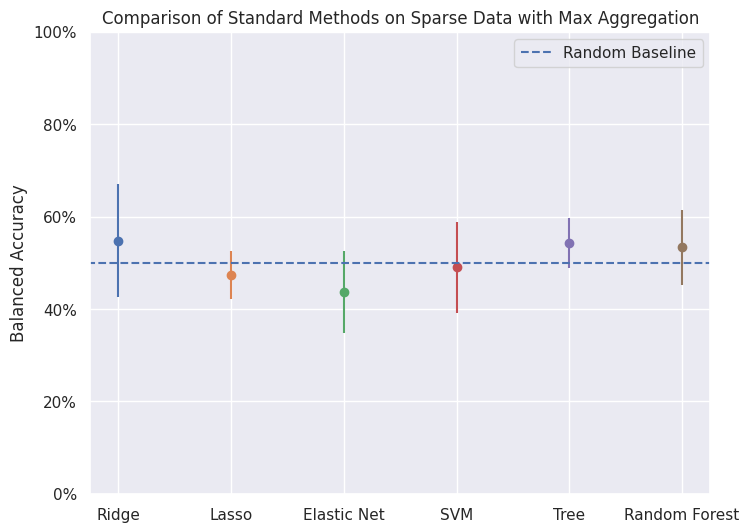

In [56]:
run_analysis_cv(get_classifiers(), X_sparse_max, y_train, "Comparison of Standard Methods on Sparse Data with Max Aggregation")

Ridge
Mean Balanced Accuracy: 0.598 +/- 0.065
Balanced Accuracy with Random Labels: 0.500
Lasso
Mean Balanced Accuracy: 0.533 +/- 0.121
Balanced Accuracy with Random Labels: 0.500
Elastic Net
Mean Balanced Accuracy: 0.574 +/- 0.036
Balanced Accuracy with Random Labels: 0.500
SVM
Mean Balanced Accuracy: 0.540 +/- 0.073
Balanced Accuracy with Random Labels: 0.500
Tree
Mean Balanced Accuracy: 0.599 +/- 0.049
Balanced Accuracy with Random Labels: 0.500
Random Forest
Mean Balanced Accuracy: 0.534 +/- 0.054
Balanced Accuracy with Random Labels: 0.500


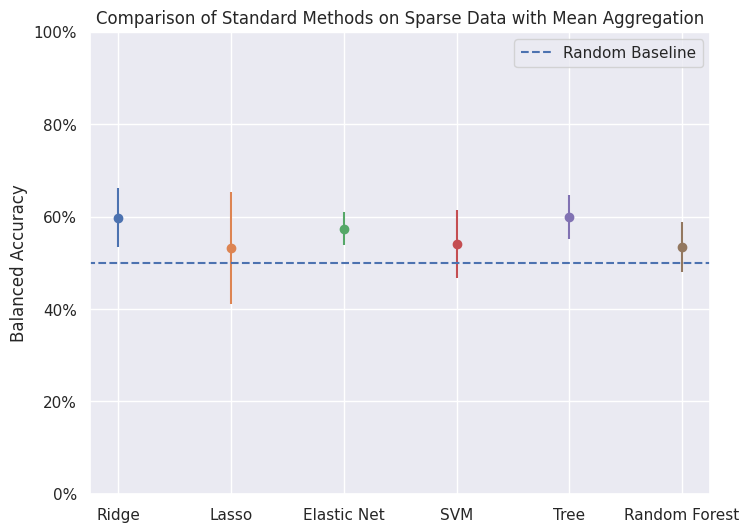

In [57]:
run_analysis_cv(get_classifiers(), X_sparse_mean, y_train, "Comparison of Standard Methods on Sparse Data with Mean Aggregation")

Ridge
Mean Balanced Accuracy: 0.523 +/- 0.043
Balanced Accuracy with Random Labels: 0.500
Lasso
Mean Balanced Accuracy: 0.458 +/- 0.050
Balanced Accuracy with Random Labels: 0.500
Elastic Net
Mean Balanced Accuracy: 0.505 +/- 0.023
Balanced Accuracy with Random Labels: 0.500
SVM
Mean Balanced Accuracy: 0.594 +/- 0.138
Balanced Accuracy with Random Labels: 0.500
Tree
Mean Balanced Accuracy: 0.542 +/- 0.104
Balanced Accuracy with Random Labels: 0.500
Random Forest
Mean Balanced Accuracy: 0.459 +/- 0.051
Balanced Accuracy with Random Labels: 0.500


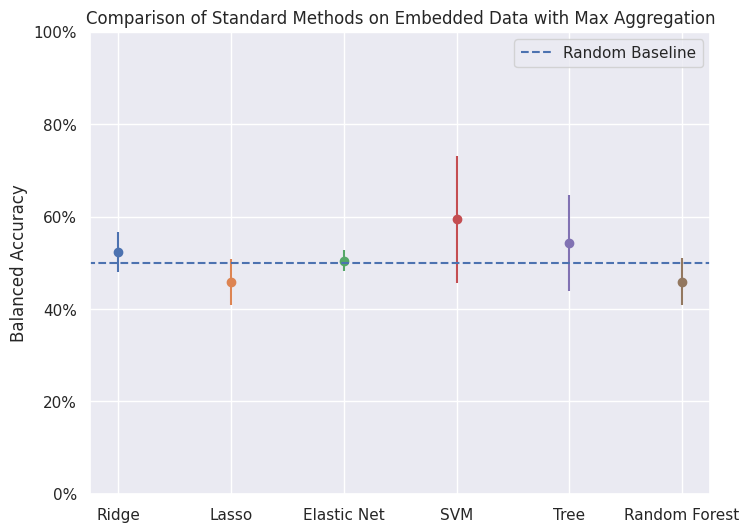

In [58]:
run_analysis_cv(get_classifiers(), X_embed_max, y_train, "Comparison of Standard Methods on Embedded Data with Max Aggregation")

Ridge
Mean Balanced Accuracy: 0.500 +/- 0.068
Balanced Accuracy with Random Labels: 0.500
Lasso
Mean Balanced Accuracy: 0.592 +/- 0.075
Balanced Accuracy with Random Labels: 0.500
Elastic Net
Mean Balanced Accuracy: 0.574 +/- 0.084
Balanced Accuracy with Random Labels: 0.500
SVM
Mean Balanced Accuracy: 0.498 +/- 0.055
Balanced Accuracy with Random Labels: 0.500
Tree
Mean Balanced Accuracy: 0.506 +/- 0.117
Balanced Accuracy with Random Labels: 0.500
Random Forest
Mean Balanced Accuracy: 0.629 +/- 0.051
Balanced Accuracy with Random Labels: 0.500


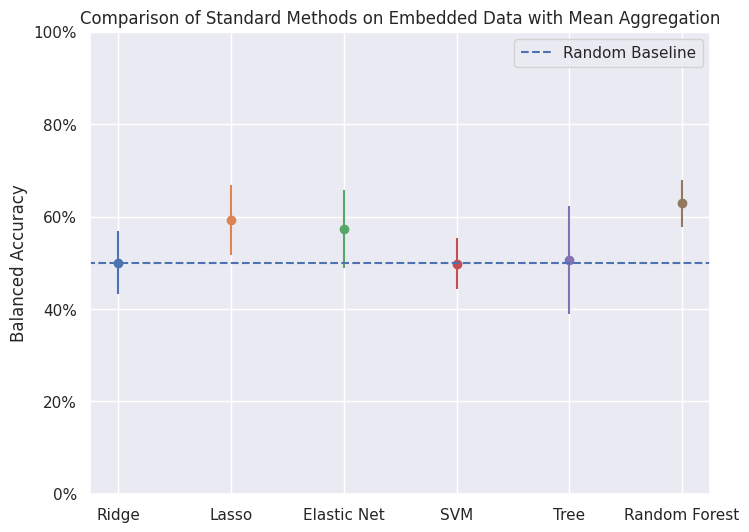

In [59]:
run_analysis_cv(get_classifiers(), X_embed_mean, y_train, "Comparison of Standard Methods on Embedded Data with Mean Aggregation")